In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm
from src.mypackage.data_preparation import prepare_statistical_data
import random
import os
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

In [2]:
df = pd.read_csv("../data/raw/PJME_hourly.csv")
train, test = prepare_statistical_data(df)

In [3]:
from itertools import product
ps = [1, 2]
ds = [1]
qs = [0, 1]
Ps = [0, 1]
Ds = [1]
Qs = [0, 1]
ss = [24]

orders = list(product(ps, ds, qs))
seasonal_orders = list(product(Ps, Ds, Qs, ss))
params = list(product(orders, seasonal_orders))

In [4]:
params

[((1, 1, 0), (0, 1, 0, 24)),
 ((1, 1, 0), (0, 1, 1, 24)),
 ((1, 1, 0), (1, 1, 0, 24)),
 ((1, 1, 0), (1, 1, 1, 24)),
 ((1, 1, 1), (0, 1, 0, 24)),
 ((1, 1, 1), (0, 1, 1, 24)),
 ((1, 1, 1), (1, 1, 0, 24)),
 ((1, 1, 1), (1, 1, 1, 24)),
 ((2, 1, 0), (0, 1, 0, 24)),
 ((2, 1, 0), (0, 1, 1, 24)),
 ((2, 1, 0), (1, 1, 0, 24)),
 ((2, 1, 0), (1, 1, 1, 24)),
 ((2, 1, 1), (0, 1, 0, 24)),
 ((2, 1, 1), (0, 1, 1, 24)),
 ((2, 1, 1), (1, 1, 0, 24)),
 ((2, 1, 1), (1, 1, 1, 24))]

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

results = []
for param in tqdm.tqdm(params):
    o, so = param
    model = SARIMAX(train["PJME_MW"][-365*24*1:], order=o, seasonal_order=so)   # 計算時間削減のため、訓練データの時間ステップは1年分とする
    result = model.fit(disp=False)
    results.append((param, result.bic))

100%|██████████| 16/16 [10:36<00:00, 39.78s/it]


In [8]:
# 最もBICが小さいモデルを選択
best_param, best_result = min(results, key=lambda x: x[1])
print(f"Best Param: {best_param}\nBIC: {best_result}")

Best Param: ((2, 1, 1), (1, 1, 1, 24))
BIC: 123350.91696272528


In [9]:
results

[(((1, 1, 0), (0, 1, 0, 24)), np.float64(127209.12088476637)),
 (((1, 1, 0), (0, 1, 1, 24)), np.float64(126021.81860079967)),
 (((1, 1, 0), (1, 1, 0, 24)), np.float64(126984.26268977695)),
 (((1, 1, 0), (1, 1, 1, 24)), np.float64(124994.72019790446)),
 (((1, 1, 1), (0, 1, 0, 24)), np.float64(125779.16588312709)),
 (((1, 1, 1), (0, 1, 1, 24)), np.float64(124253.04111729642)),
 (((1, 1, 1), (1, 1, 0, 24)), np.float64(125353.96387742806)),
 (((1, 1, 1), (1, 1, 1, 24)), np.float64(123504.43689533575)),
 (((2, 1, 0), (0, 1, 0, 24)), np.float64(125658.64604038323)),
 (((2, 1, 0), (0, 1, 1, 24)), np.float64(124281.7422479173)),
 (((2, 1, 0), (1, 1, 0, 24)), np.float64(125276.65605887894)),
 (((2, 1, 0), (1, 1, 1, 24)), np.float64(123459.0415665225)),
 (((2, 1, 1), (0, 1, 0, 24)), np.float64(125593.51638777358)),
 (((2, 1, 1), (0, 1, 1, 24)), np.float64(124083.71765914586)),
 (((2, 1, 1), (1, 1, 0, 24)), np.float64(125151.90922935671)),
 (((2, 1, 1), (1, 1, 1, 24)), np.float64(123350.916962725

In [31]:
model = SARIMAX(train["PJME_MW"][-365*24*1:], order=best_param[0], seasonal_order=best_param[1])
result = model.fit(disp=False)

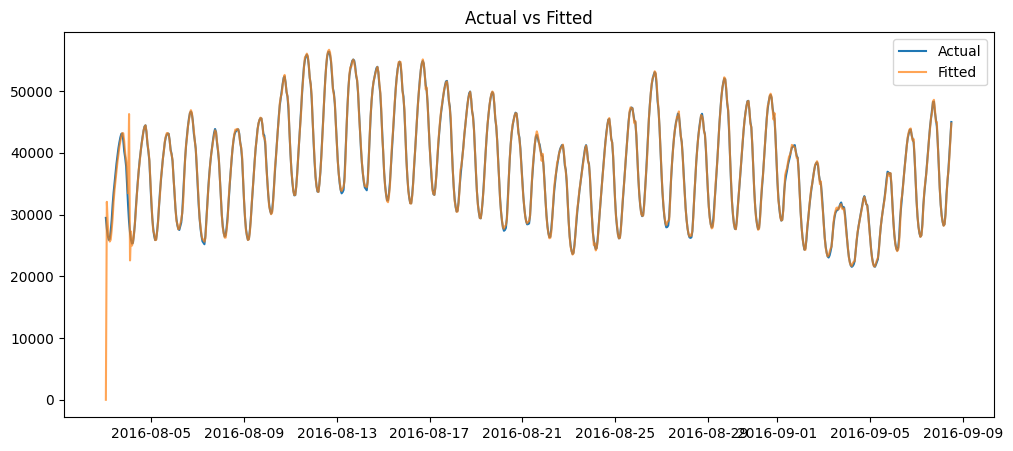

In [32]:
plt.figure(figsize=(12, 5))
plt.plot(train["Datetime"][-365*24*1:int(-365*24*0.9)], train["PJME_MW"][-365*24*1:int(-365*24*0.9)], label="Actual")
plt.plot(train["Datetime"][-365*24*1:int(-365*24*0.9)], result.fittedvalues[-365*24*1:int(-365*24*0.9)], label="Fitted", alpha=0.7)

plt.legend()
plt.title("Actual vs Fitted")
plt.show()

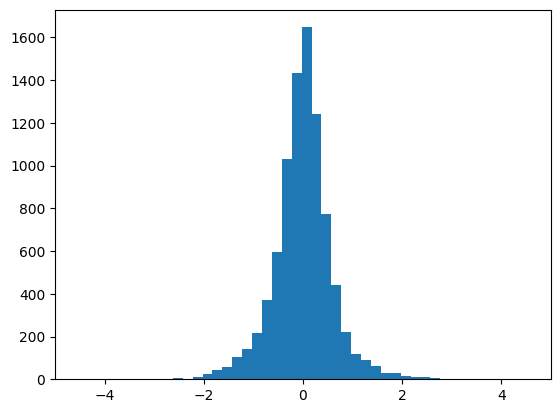

In [33]:
plt.hist((result.resid - result.resid.mean()) / result.resid.std(), bins=500)
plt.xlim(-5, 5)
plt.show()

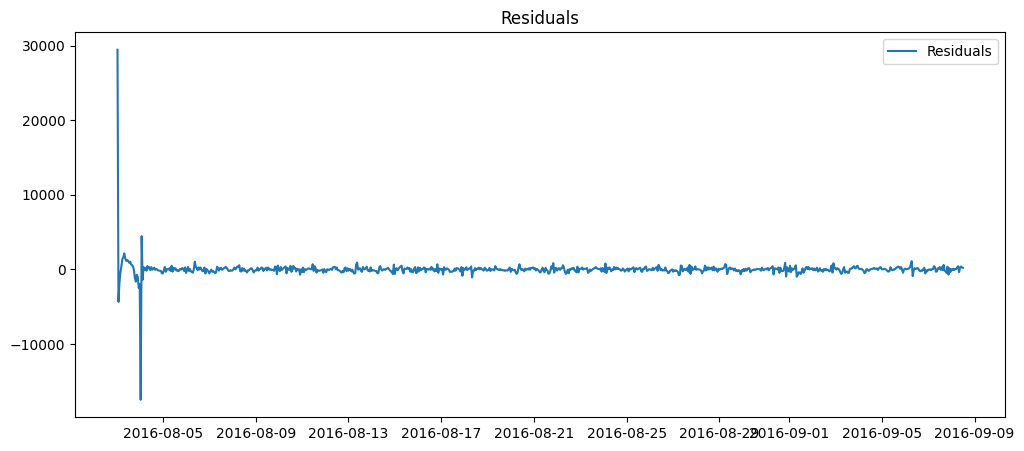

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(train["Datetime"][-365*24*1:int(-365*24*0.9)], result.resid[-365*24*1:int(-365*24*0.9)], label="Residuals")

plt.legend()
plt.title("Residuals")
plt.show()

In [35]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(result.resid[50:], lags=[24], return_df=True)

,lb_stat,lb_pvalue
24,416.855239,2.581150e-73


In [36]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            PJME_MW   No. Observations:                 8760
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -61648.233
Date:                            Sat, 02 May 2026   AIC                         123308.466
Time:                                    16:33:48   BIC                         123350.917
Sample:                                         0   HQIC                        123322.933
                                           - 8760                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8308      0.020     42.360      0.000       0.792       0.869
ar.L2         -0.2478      0.017    -14.806      0.000      -0.281      -0.215
ma.L1          0.2574      0.019     13.378      0.000       0.220       0.295
ar.S.L24       0.3372      0.009     35.865      0.000       0.319       0.356
ma.S.L24      -0.8503      0.006   -147.466      0.000      -0.862      -0.839
sigma2      7.708e+04    614.482    125.432      0.000    7.59e+04    7.83e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.77   Jarque-Bera (JB):             16580.87
Prob(Q):                              0.38   Prob(JB):                         0.00
Heteroskedasticity (H):               0.79   Skew:                             0.09
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [37]:
test

,Datetime,PJME_MW
136606,2017-08-03 01:00:00,29189.0
136607,2017-08-03 02:00:00,27584.0
136608,2017-08-03 03:00:00,26544.0
136609,2017-08-03 04:00:00,26012.0
136610,2017-08-03 05:00:00,26187.0
...,...,...
145361,2018-08-02 20:00:00,44057.0
145362,2018-08-02 21:00:00,43256.0
145363,2018-08-02 22:00:00,41552.0
145364,2018-08-02 23:00:00,38500.0


In [ ]:
preds = []
q, r = divmod(len(test), 24)
start = 0
if r == 0:
    r = 24
else:
    q += 1
for t in range(0, q):
    if t == q - 1:
        pred_len = r
    else:
        pred_len = 24
    end = start + pred_len
    pred = result.forecast(steps=pred_len)
    preds.extend(pred)
    result = result.extend(test["PJME_MW"][start:end])
    start = end

ValueError: Prediction must have `end` after `start`.

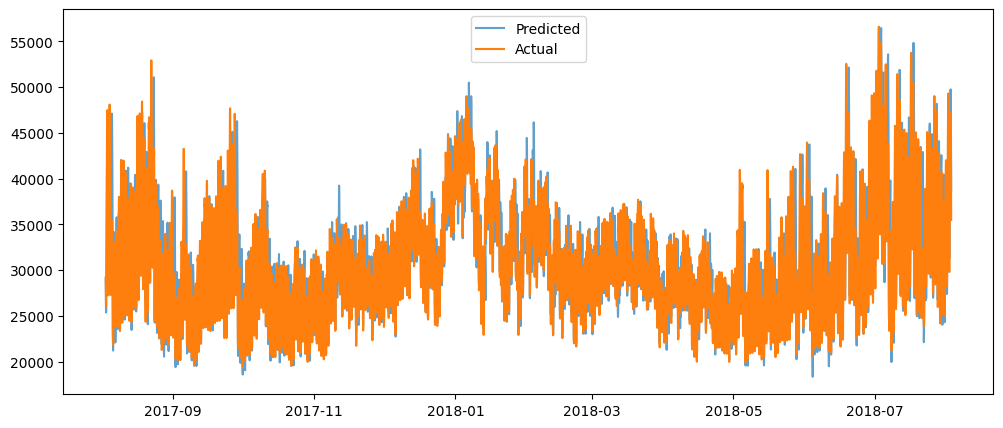

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(test["Datetime"], preds, label="Predicted", alpha=0.7)
plt.plot(test["Datetime"], test["PJME_MW"].values, label="Actual")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(test["PJME_MW"].values, preds)
rmse = root_mean_squared_error(test["PJME_MW"].values, preds)
mape = mean_absolute_percentage_error(test["PJME_MW"].values, preds)

print(f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape*100:.2f}%")

MAE: 1792.56
RMSE: 2601.28
MAPE: 5.57%


In [58]:
# 試しに1週間の予測をやってみる
model = SARIMAX(train["PJME_MW"][-365*24*1:], order=best_param[0], seasonal_order=best_param[1])
result = model.fit(disp=False)

preds = []
q, r = divmod(len(test), 24*7)
start = 0
if r == 0:
    r = 24*7
else:
    q += 1
for t in range(0, q):
    if t == q - 1:
        pred_len = r
    else:
        pred_len = 24*7
    end = start + pred_len
    pred = result.forecast(steps=pred_len)
    preds.extend(pred)
    result = result.extend(test["PJME_MW"][start:end])
    start = end

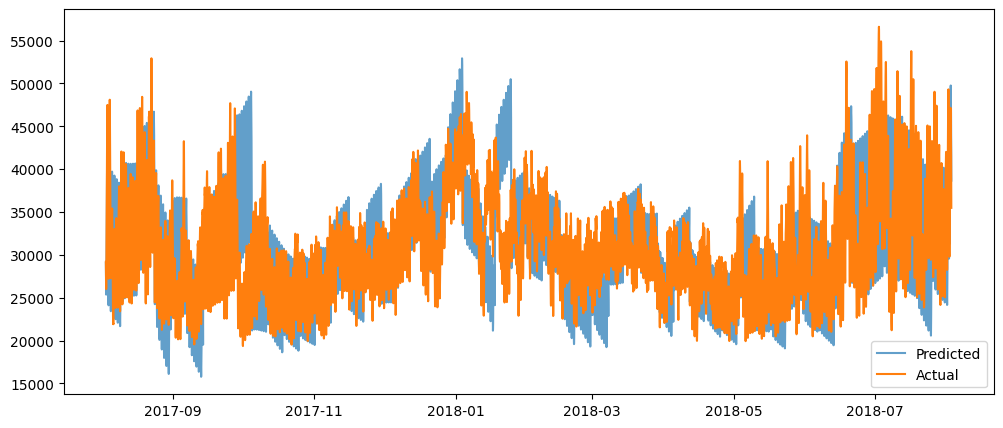

In [59]:
plt.figure(figsize=(12, 5))
plt.plot(test["Datetime"], preds, label="Predicted", alpha=0.7)
plt.plot(test["Datetime"], test["PJME_MW"].values, label="Actual")
plt.legend()
plt.show()

In [60]:
mae = mean_absolute_error(test["PJME_MW"].values, preds)
rmse = root_mean_squared_error(test["PJME_MW"].values, preds)
mape = mean_absolute_percentage_error(test["PJME_MW"].values, preds)

print(f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape*100:.2f}%")

MAE: 3404.72
RMSE: 4702.46
MAPE: 11.03%


In [54]:
# 試しに1か月の予測をやってみる
model = SARIMAX(train["PJME_MW"][-365*24*1:], order=best_param[0], seasonal_order=best_param[1])
result = model.fit(disp=False)

preds = []
q, r = divmod(len(test), 24*30)
start = 0
if r == 0:
    r = 24*30
else:
    q += 1
for t in range(0, q):
    if t == q - 1:
        pred_len = r
    else:
        pred_len = 24*30
    end = start + pred_len
    pred = result.forecast(steps=pred_len)
    preds.extend(pred)
    result = result.extend(test["PJME_MW"][start:end])
    start = end

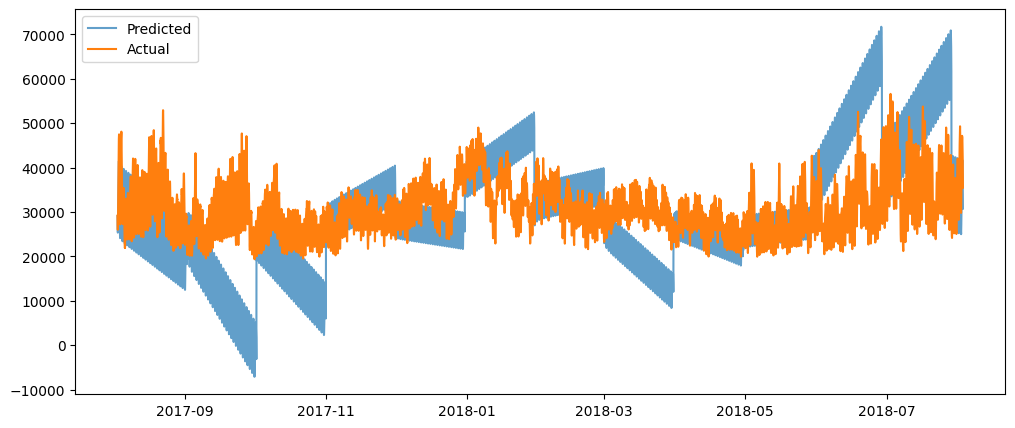

In [56]:
plt.figure(figsize=(12, 5))
plt.plot(test["Datetime"], preds, label="Predicted", alpha=0.7)
plt.plot(test["Datetime"], test["PJME_MW"].values, label="Actual")
plt.legend()
plt.show()

In [57]:
mae = mean_absolute_error(test["PJME_MW"].values, preds)
rmse = root_mean_squared_error(test["PJME_MW"].values, preds)
mape = mean_absolute_percentage_error(test["PJME_MW"].values, preds)

print(f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape*100:.2f}%")

MAE: 8899.93
RMSE: 11846.18
MAPE: 29.08%


In [ ]:
# 1日分の予測は良い。
# 1週間分の予測は精度が落ちる。
# 1か月分の予測をさせると役に立たない。